In [1]:
import os

import geopandas as gpd
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap

In [2]:
# Raiz das fontes brutas (fora do repo). Se a unidade mudar, muda so esta linha.
RAIZ_SPTRANS = r"C:\Users\9837292\Desktop\SSD\SPTrans"

od = 2023

In [ ]:
if od == 2023:
    zonas = gpd.read_file(r"..\Dados\pacote-anexos-od_10-02-25_0\002_Site Metro Mapas\Shape\Zonas_2023.shp")
elif od == 2017:
    zonas = gpd.read_file(r"..\Dados\OD-2017\Mapas-OD2017\Shape-OD2017\Zonas_2017_region.shp")
zonas

<Axes: >

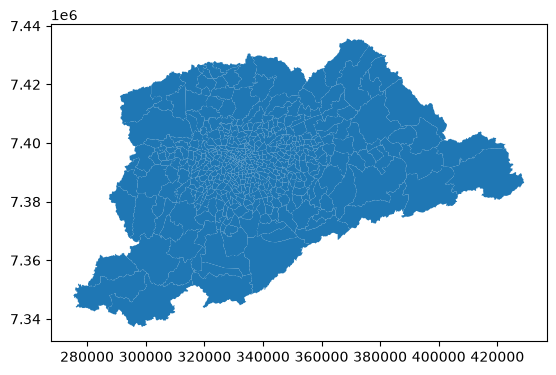

In [4]:
zonas.plot()

In [41]:
linhas = gpd.read_file(os.path.join(RAIZ_SPTRANS,
                                    "pedido 096411 - histórico de linhas e mudanças",
                                    "Linhas - 2023 a 2026.gpkg"))
split_df = linhas["trip_id"].str.split("-", expand=True)
linhas["line_name"] = split_df[0] + "-" + split_df[1]
linhas = linhas.drop_duplicates(subset=['line_name'], keep='first')
linhas

,ano,trip_id,geometry,line_name
0,2023,1012-10-0,"LINESTRING (-46.7871 -23.43217, -46.7871 -23.4...",1012-10
2,2023,1012-21-0,"LINESTRING (-46.8019 -23.43907, -46.80201 -23....",1012-21
3,2023,1015-10-0,"LINESTRING (-46.78704 -23.43252, -46.78704 -23...",1015-10
4,2023,1016-10-0,"LINESTRING (-46.61103 -23.44673, -46.61111 -23...",1016-10
6,2023,1017-10-0,"LINESTRING (-46.75059 -23.41409, -46.75056 -23...",1017-10
...,...,...,...,...
8429,2026,7004-22-0,"LINESTRING (-46.78855 -23.73582, -46.78823 -23...",7004-22
8598,2026,8006-21-0,"LINESTRING (-46.72649 -23.48652, -46.72644 -23...",8006-21
8895,2026,920P-10-0,"LINESTRING (-46.63028 -23.54749, -46.63025 -23...",920P-10
8920,2026,955P-10-0,"LINESTRING (-46.60705 -23.57977, -46.60705 -23...",955P-10


In [55]:
linhas.loc[linhas["ano"]=="2023"].to_crs(4326)

,ano,trip_id,geometry,line_name,Metrô,CPTM
0,2023,1012-10-0,"LINESTRING (-46.7871 -23.43217, -46.7871 -23.4...",1012-10,0,0
2,2023,1012-21-0,"LINESTRING (-46.8019 -23.43907, -46.80201 -23....",1012-21,0,0
3,2023,1015-10-0,"LINESTRING (-46.78704 -23.43252, -46.78704 -23...",1015-10,0,0
4,2023,1016-10-0,"LINESTRING (-46.61103 -23.44673, -46.61111 -23...",1016-10,0,0
6,2023,1017-10-0,"LINESTRING (-46.75059 -23.41409, -46.75056 -23...",1017-10,0,0
...,...,...,...,...,...,...
2291,2023,N839-11-0,"LINESTRING (-46.70929 -23.57174, -46.70934 -23...",N839-11,0,0
2292,2023,N840-11-0,"LINESTRING (-46.63366 -23.58946, -46.6337 -23....",N840-11,0,0
2293,2023,N841-11-0,"LINESTRING (-46.63427 -23.58951, -46.63433 -23...",N841-11,0,0
2294,2023,N842-11-0,"LINESTRING (-46.70187 -23.5662, -46.70183 -23....",N842-11,0,0


In [46]:
linhas["Metrô"] = 0
linhas.loc[linhas["line_name"].str.contains("METRÔ"),"Metrô"] = 1
linhas["CPTM"] = 0
linhas.loc[linhas["line_name"].str.contains("CPTM"),"CPTM"] = 1
linhas.loc[(linhas["Metrô"]==1)|(linhas["CPTM"]==1)]

,ano,trip_id,geometry,line_name,Metrô,CPTM
2066,2023,CPTM L07-0-0,"LINESTRING (-46.63535 -23.53517, -46.63548 -23...",CPTM L07-0,0,1
2068,2023,CPTM L08-0-0,"LINESTRING (-46.64074 -23.53302, -46.64078 -23...",CPTM L08-0,0,1
2070,2023,CPTM L09-0-0,"LINESTRING (-46.77604 -23.52762, -46.77591 -23...",CPTM L09-0,0,1
2072,2023,CPTM L10-0-0,"LINESTRING (-46.61651 -23.54531, -46.61623 -23...",CPTM L10-0,0,1
2074,2023,CPTM L11-0-0,"LINESTRING (-46.63535 -23.53517, -46.6341 -23....",CPTM L11-0,0,1
2076,2023,CPTM L12-0-0,"LINESTRING (-46.61651 -23.54531, -46.61623 -23...",CPTM L12-0,0,1
2078,2023,CPTM L13-0-0,"LINESTRING (-46.52005 -23.49826, -46.5198 -23....",CPTM L13-0,0,1
2080,2023,METRÔ 15-0-0,"LINESTRING (-46.58343 -23.5846, -46.58287 -23....",METRÔ 15-0,1,0
2082,2023,METRÔ L1-0-0,"LINESTRING (-46.64105 -23.64635, -46.64118 -23...",METRÔ L1-0,1,0
2084,2023,METRÔ L2-0-0,"LINESTRING (-46.58193 -23.58443, -46.58204 -23...",METRÔ L2-0,1,0


In [ ]:
demanda_mes = pd.read_parquet("../outputs/01/Dados_4Meses_2023_2024_mes.parquet")
demanda_mes

In [7]:
demanda_mes.loc[demanda_mes["Ano"]=="2023"].value_counts("zona_emb")

zona_emb
304.0    1236
2.0      1232
303.0    1182
100.0     941
129.0     934
         ... 
351.0      12
300.0      12
399.0      12
400.0      12
999.0      12
Name: count, Length: 387, dtype: int64

In [8]:
# 2. Join the spatial 'zonas' GeoDataFrame with the demand data
# Using a left join to keep all zones, even those without trips in this specific timeframe
zonas_demanda_2024 = zonas.merge(
    demanda_mes.loc[(demanda_mes["Ano"]=="2024")&(demanda_mes["Mês"]=="04")], 
    left_on="NumeroZona", 
    right_on="zona_emb", 
    how="left",
    #suffixes=["_2024"]
)
print(len(zonas_demanda_2024))

zonas_demanda_2023 = zonas.merge(
    demanda_mes.loc[(demanda_mes["Ano"]=="2023")&(demanda_mes["Mês"]=="04")], 
    left_on=["NumeroZona"], 
    right_on=["zona_emb"], 
    how="left",
)
print(len(zonas_demanda_2023))

11051
10776


In [9]:
zonas_demanda_2023

,NumeroZona,NomeZona,NumeroMuni,NomeMunici,NumDistrit,NomeDistri,Area_ha_2,geometry,linha_blt,zona_emb,Ano,Mês,N_embarques
0,1,Sé,36,São Paulo,80,Sé,57.10,"POLYGON ((333739.415 7394619.838, 333792.438 7...",3160-10,1.0,2023,04,94.0
1,1,Sé,36,São Paulo,80,Sé,57.10,"POLYGON ((333739.415 7394619.838, 333792.438 7...",5300-10,1.0,2023,04,1410.0
2,1,Sé,36,São Paulo,80,Sé,57.10,"POLYGON ((333739.415 7394619.838, 333792.438 7...",5185-10,1.0,2023,04,771.0
3,1,Sé,36,São Paulo,80,Sé,57.10,"POLYGON ((333739.415 7394619.838, 333792.438 7...",8615-10,1.0,2023,04,498.0
4,1,Sé,36,São Paulo,80,Sé,57.10,"POLYGON ((333739.415 7394619.838, 333792.438 7...",408A-10,1.0,2023,04,107.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10771,523,Quatro Encruzilhadas,17,Itapevi,113,Itapevi,2101.43,"POLYGON ((300336.368 7389696.621, 300324.32 73...",NaN,NaN,NaN,NaN,NaN
10772,524,Itapevi,17,Itapevi,113,Itapevi,1070.03,"POLYGON ((303326.146 7397176.35, 303326.146 73...",NaN,524.0,2023,04,21281.0
10773,525,Amador Bueno,17,Itapevi,113,Itapevi,5113.23,"POLYGON ((303292.377 7397174.79, 303326.146 73...",NaN,NaN,NaN,NaN,NaN
10774,526,Santana de Parnaíba,31,Santana de Parnaíba,127,Santana de Parnaíba,18034.76,"POLYGON ((296271.998 7398946.927, 296196.397 7...",NaN,NaN,NaN,NaN,NaN


In [10]:
zonas_demanda_2024.columns

Index(['NumeroZona', 'NomeZona', 'NumeroMuni', 'NomeMunici', 'NumDistrit',
       'NomeDistri', 'Area_ha_2', 'geometry', 'linha_blt', 'zona_emb', 'Ano',
       'Mês', 'N_embarques'],
      dtype='str')

In [11]:
zonas_demanda = zonas.merge(
    pd.DataFrame(zonas_demanda_2024.groupby(['NumeroZona'])["N_embarques"].sum()).reset_index().replace(0,np.nan),
    left_on="NumeroZona",
    right_on="NumeroZona",
    how="left",
)
zonas_demanda = zonas_demanda.rename(columns={"N_embarques":"N_embarques_2024"})

zonas_demanda = zonas_demanda.merge(
    pd.DataFrame(zonas_demanda_2023.groupby(['NumeroZona'])["N_embarques"].sum()).reset_index().replace(0,np.nan),
    left_on="NumeroZona",
    right_on="NumeroZona",
    how="left",
)
zonas_demanda = zonas_demanda.rename(columns={"N_embarques":"N_embarques_2023"})
zonas_demanda = gpd.GeoDataFrame(zonas_demanda)

zonas_demanda

,NumeroZona,NomeZona,NumeroMuni,NomeMunici,NumDistrit,NomeDistri,Area_ha_2,geometry,N_embarques_2024,N_embarques_2023
0,1,Sé,36,São Paulo,80,Sé,57.10,"POLYGON ((333739.415 7394619.838, 333792.438 7...",99299.0,68864.0
1,2,Parque Dom Pedro,36,São Paulo,80,Sé,113.64,"POLYGON ((333106.146 7395425.48, 333120.09 739...",493537.0,229813.0
2,3,Praça João Mendes,36,São Paulo,80,Sé,47.75,"POLYGON ((333353.211 7393933.156, 333238.044 7...",104649.0,83400.0
3,4,Ladeira da Memória,36,São Paulo,67,República,75.11,"POLYGON ((332742.619 7394795.328, 332742.537 7...",142380.0,76110.0
4,5,República,36,São Paulo,67,República,74.95,"POLYGON ((332983.962 7395262.578, 333004.239 7...",231917.0,165153.0
...,...,...,...,...,...,...,...,...,...,...
522,523,Quatro Encruzilhadas,17,Itapevi,113,Itapevi,2101.43,"POLYGON ((300336.368 7389696.621, 300324.32 73...",NaN,NaN
523,524,Itapevi,17,Itapevi,113,Itapevi,1070.03,"POLYGON ((303326.146 7397176.35, 303326.146 73...",23720.0,21281.0
524,525,Amador Bueno,17,Itapevi,113,Itapevi,5113.23,"POLYGON ((303292.377 7397174.79, 303326.146 73...",NaN,NaN
525,526,Santana de Parnaíba,31,Santana de Parnaíba,127,Santana de Parnaíba,18034.76,"POLYGON ((296271.998 7398946.927, 296196.397 7...",NaN,NaN


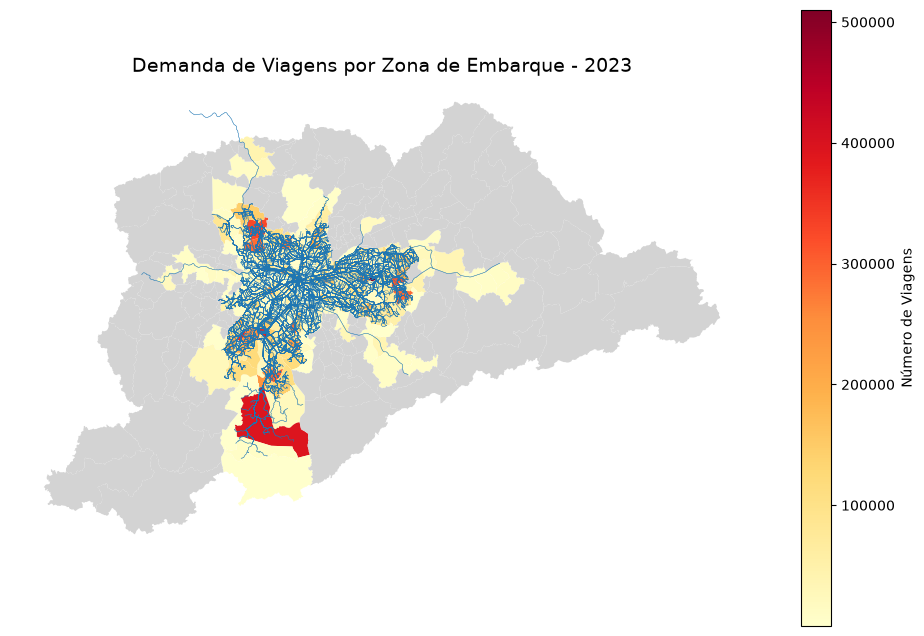

In [12]:
# 3. Plot the result
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

ano = 2023

zonas_demanda.plot(
    column="N_embarques_{}".format(ano),              # The column we created earlier to count rows
    cmap="YlOrRd",                   # Yellow to Red colormap (great for density/heatmaps)
    legend=True,
    legend_kwds={"label": "Número de Viagens"},
    missing_kwds={"color": "lightgrey"}, # Zones with no matches will be grey
    ax=ax
)

linhas.loc[linhas["ano"]==str(ano)].to_crs("22523").plot(
    linewidth=0.3,
    alpha=0.8,
    ax=ax
    )

# Clean up the map visual
ax.set_title("Demanda de Viagens por Zona de Embarque - {}".format(ano), fontsize=14)
ax.set_axis_off()

plt.show()

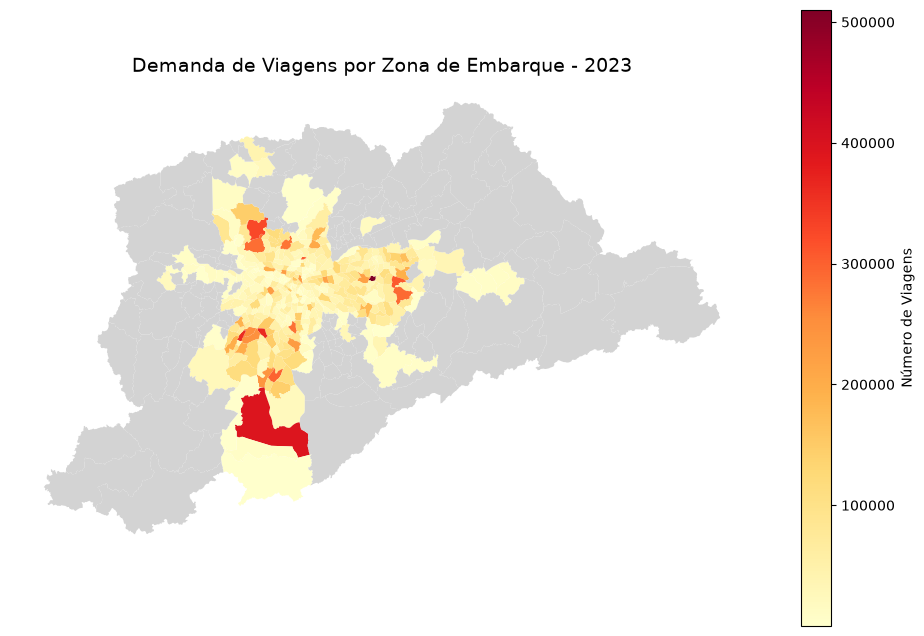

In [13]:
# 3. Plot the result
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

ano = 2023

zonas_demanda.plot(
    column="N_embarques_{}".format(ano),              # The column we created earlier to count rows
    cmap="YlOrRd",                   # Yellow to Red colormap (great for density/heatmaps)
    legend=True,
    legend_kwds={"label": "Número de Viagens"},
    missing_kwds={"color": "lightgrey"}, # Zones with no matches will be grey
    ax=ax
)

# Clean up the map visual
ax.set_title("Demanda de Viagens por Zona de Embarque - {}".format(ano), fontsize=14)
ax.set_axis_off()

plt.show()

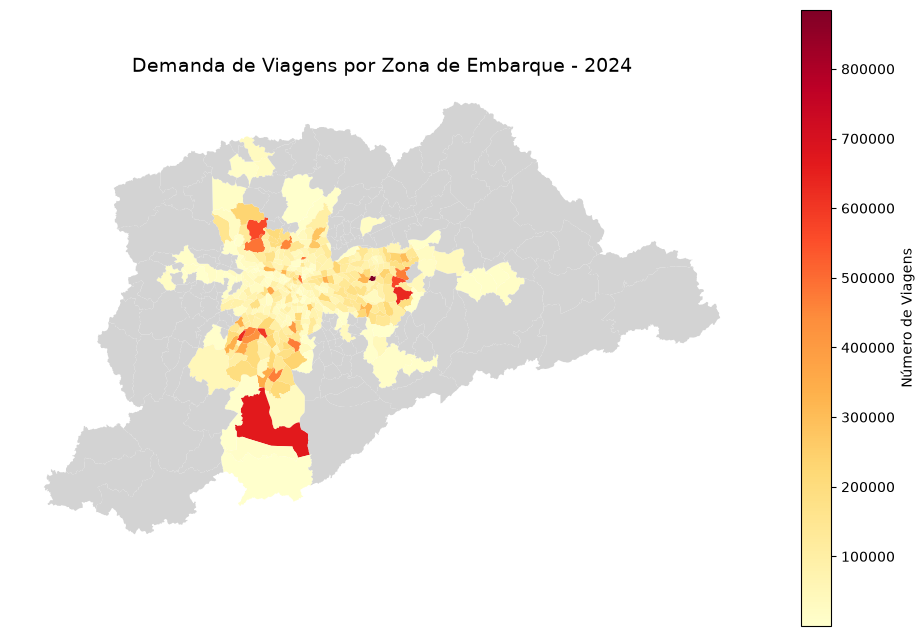

In [14]:
# 3. Plot the result
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

ano = 2024

zonas_demanda.plot(
    column="N_embarques_{}".format(ano),              # The column we created earlier to count rows
    cmap="YlOrRd",                   # Yellow to Red colormap (great for density/heatmaps)
    legend=True,
    legend_kwds={"label": "Número de Viagens"},
    missing_kwds={"color": "lightgrey"}, # Zones with no matches will be grey
    ax=ax
)

# Clean up the map visual
ax.set_title("Demanda de Viagens por Zona de Embarque - {}".format(ano), fontsize=14)
ax.set_axis_off()

plt.show()

In [15]:
zonas_demanda["Diff_embarques"] = zonas_demanda["N_embarques_2024"] - zonas_demanda["N_embarques_2023"]

In [ ]:
import folium
import branca.colormap as cm
import numpy as np

# 1. Convert to WGS84 and simplify geometry for the web
zonas_demanda_4326 = zonas_demanda.to_crs(epsg=4326)
zonas_demanda_4326.geometry = zonas_demanda_4326.geometry.simplify(tolerance=0.0005)

# Calculate map center
centro_y = zonas_demanda_4326.geometry.centroid.y.mean()
centro_x = zonas_demanda_4326.geometry.centroid.x.mean()

# Initialize the Folium map
m = folium.Map(
    location=[centro_y, centro_x], 
    zoom_start=11, 
    tiles="CartoDB positron"
)

# ==========================================
# LAYER 1: Demand 2023 (Replaces Matplotlib)
# ==========================================
ano = 2023
col_embarques = f"N_embarques_{ano}"

# Handle missing values for min/max calculation
vmin_2023 = zonas_demanda_4326[col_embarques].min()
vmax_2023 = zonas_demanda_4326[col_embarques].max()

# Create a YlOrRd colormap (similar to Matplotlib's "YlOrRd")
colormap_2023 = cm.linear.YlOrRd_09.scale(vmin_2023, vmax_2023)
colormap_2023.caption = f"Número de Viagens - {ano}"

def style_function_2023(feature):
    val = feature["properties"][col_embarques]
    return {
        "fillColor": "lightgrey" if val is None or np.isnan(val) else colormap_2023(val),
        "color": "#333333",
        "weight": 0.6,
        "fillOpacity": 0.75
    }

folium.GeoJson(
    zonas_demanda_4326.__geo_interface__,
    name=f"Demanda de Viagens {ano}", # This name appears in the toggle menu
    style_function=style_function_2023,
    tooltip=folium.GeoJsonTooltip(
        fields=["NumeroZona", "NomeZona", col_embarques],
        aliases=["Zona OD:", "Nome da Zona:", f"Embarques {ano}:"],
        localize=True,
        sticky=True
    ),
    show=True # This layer is ON by default
).add_to(m)

# ==========================================
# LAYER 2: Demand 2024 (Replaces Matplotlib)
# ==========================================
ano = 2024
col_embarques = f"N_embarques_{ano}"

# Handle missing values for min/max calculation
vmin_2024 = zonas_demanda_4326[col_embarques].min()
vmax_2024 = zonas_demanda_4326[col_embarques].max()

# Create a YlOrRd colormap (similar to Matplotlib's "YlOrRd")
colormap_2024 = cm.linear.YlOrRd_09.scale(vmin_2024, vmax_2024)
colormap_2024.caption = f"Número de Viagens - {ano}"

def style_function_2024(feature):
    val = feature["properties"][col_embarques]
    return {
        "fillColor": "lightgrey" if val is None or np.isnan(val) else colormap_2024(val),
        "color": "#333333",
        "weight": 0.6,
        "fillOpacity": 0.75
    }

folium.GeoJson(
    zonas_demanda_4326.__geo_interface__,
    name=f"Demanda de Viagens {ano}", # This name appears in the toggle menu
    style_function=style_function_2024,
    tooltip=folium.GeoJsonTooltip(
        fields=["NumeroZona", "NomeZona", col_embarques],
        aliases=["Zona OD:", "Nome da Zona:", f"Embarques {ano}:"],
        localize=True,
        sticky=True
    ),
    show=False # This layer is ON by default
).add_to(m)

# ==========================================
# LAYER 3: Difference 2024 x 2023
# ==========================================
vmin_diff = zonas_demanda_4326["Diff_embarques"].min()
vmax_diff = zonas_demanda_4326["Diff_embarques"].max()

if vmin_diff >= 0: vmin_diff = -0.1
if vmax_diff <= 0: vmax_diff = 0.1

colormap_diff = cm.LinearColormap(
    colors=["#d7191c", "#ffffff", "#1a9641"],
    index=[vmin_diff, 0, vmax_diff],
    vmin=vmin_diff,
    vmax=vmax_diff
)
colormap_diff.caption = "Diferença entre Embarques (2024 x 2023)"

def style_function_diff(feature):
    val = feature["properties"]["Diff_embarques"]
    return {
        "fillColor": "lightgrey" if val is None or np.isnan(val) else colormap_diff(val),
        "color": "#333333",  
        "weight": 0.6,       
        "fillOpacity": 0.75  
    }

folium.GeoJson(
    zonas_demanda_4326.__geo_interface__,
    name="Diferença de Embarques", # This name appears in the toggle menu
    style_function=style_function_diff,
    tooltip=folium.GeoJsonTooltip(
        fields=["NumeroZona", "NomeZona", "Diff_embarques"],
        aliases=["Zona OD:", "Nome da Zona:", "Diferença:"],
        localize=True,
        sticky=True
    ),
    show=False # This layer is OFF by default, so they don't overlap
).add_to(m)

# ==========================================
# LAYER 4: Linhas Ônibus 2024
# ==========================================

linhas_onibus_4326 = linhas.loc[((linhas["ano"]=="2024")|(linhas["ano"]=="2023"))&((linhas["Metrô"]==0)&(linhas["CPTM"]==0))].to_crs(4326)
linhas_onibus_4326.geometry = linhas_onibus_4326.geometry.simplify(tolerance=0.0005)

folium.GeoJson(
    linhas_onibus_4326.__geo_interface__,
    name="Linhas Ônibus 2024", # This name appears in the toggle menu
    tooltip=folium.GeoJsonTooltip(
        fields=["line_name"],
        aliases=["Nome da Linha:"],
        localize=True,
        sticky=True
    ),
    show=True # This layer is OFF by default, so they don't overlap
).add_to(m)

# ==========================================
# LAYER 5: Linhas Metrô e Trem
# ==========================================

linhas_trilhos_4326 = linhas.loc[(linhas["Metrô"]==1)|(linhas["CPTM"]==1)].to_crs(4326)
linhas_trilhos_4326.geometry = linhas_trilhos_4326.geometry.simplify(tolerance=0.0005)

folium.GeoJson(
    linhas_trilhos_4326.__geo_interface__,
    name="Linhas Metrô e Trem", # This name appears in the toggle menu
    style_function=lambda feature: {"color": "green", "weight": 4},
    tooltip=folium.GeoJsonTooltip(
        fields=["trip_id"],
        aliases=["Nome da Linha:"],
        localize=True,
        sticky=True
    ),
    show=True # This layer is OFF by default, so they don't overlap
).add_to(m)

# ==========================================
# FINALIZE MAP
# ==========================================

# Add both legends to the map
colormap_2023.add_to(m)
colormap_2024.add_to(m)
colormap_diff.add_to(m)

# Add the Layer Control so the user can toggle between the layers
folium.LayerControl(collapsed=False).add_to(m)

# Save and show
m.save("../docs/mapa_diferenca_demanda.html")
m